# 주요 6개국 외식 물가 트렌드 분석

**데이터:** OECD 소비자물가지수 (음식 및 숙박 CP11, 식료품 CP01, 에너지 CP045, 전체 CPI)
**대상:** 한국, 미국, 일본, 영국, 독일, 프랑스
**분석 기간:** 2015-01 ~ 2024-12 (월별)

**분석 질문**
1. 2015년 이후 한국 외식 물가 상승률은 주요국보다 높았는가?
2. 급등 구간의 시작 시점과 크기는 나라별로 달랐는가? 코로나19(2020.03), 러시아-우크라이나 전쟁(2022.02), 이스라엘-하마스 전쟁(2023.10) 전후로 무엇이 달라졌는가?

> 데이터 수집은 `collect_data.py`를 먼저 실행한다. 해석과 결론은 `REPORT.md`에 정리한다.

## 0. 준비

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "font.family": "Malgun Gothic",  # 한글 표시 (Windows 기본 글꼴)
    "axes.unicode_minus": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "text.color": "#0b0b0b",
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

IMG_DIR = Path("images")
IMG_DIR.mkdir(exist_ok=True)

START, END = "2015-01-01", "2024-12-01"
COUNTRY_NAMES = {"KOR": "한국", "USA": "미국", "JPN": "일본", "GBR": "영국", "DEU": "독일", "FRA": "프랑스"}
COLORS = {"KOR": "#2a78d6", "USA": "#eb6834", "JPN": "#1baf7a", "GBR": "#eda100", "DEU": "#e87ba4", "FRA": "#008300"}
EVENTS = {
    "코로나19": pd.Timestamp("2020-03-01"),
    "러-우 전쟁": pd.Timestamp("2022-02-01"),
    "이-하 전쟁": pd.Timestamp("2023-10-01"),
}


EVENT_MARKS = {"코로나19": "①", "러-우 전쟁": "②", "이-하 전쟁": "③"}


def mark_events(ax, label=True, short=False):
    """사건 시점을 세로 점선으로 표시한다. 좁은 그래프에서는 short=True로 번호만 표시한다."""
    for name, date in EVENTS.items():
        ax.axvline(date, color="#898781", linestyle="--", linewidth=1)
        if label:
            ax.text(date, 1.01, EVENT_MARKS[name] if short else name, transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=9, color="#52514e")


def format_year_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

## 1. 데이터 기본 정보 확인

In [2]:
df = pd.read_csv("data/cpi_monthly.csv", parse_dates=["date"])
df.info()
print("\n수집 기간:", df["date"].min().date(), "~", df["date"].max().date())
print("\n컬럼별 결측값 수:")
print(df.isna().sum())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3566 entries, 0 to 3565
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   country      3566 non-null   object        
 1   category     3566 non-null   object        
 2   date         3566 non-null   datetime64[ns]
 3   index        3566 non-null   float64       
 4   base_period  3566 non-null   int64         
 5   source       3566 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 167.3+ KB

수집 기간: 2014-01-01 ~ 2026-08-01

컬럼별 결측값 수:
country        0
category       0
date           0
index          0
base_period    0
source         0
dtype: int64


,country,category,date,index,base_period,source
0,DEU,all_items,2014-01-01,98.79630,2015,OECD coicop1999
1,DEU,all_items,2014-02-01,99.26276,2015,OECD coicop1999
2,DEU,all_items,2014-03-01,99.54263,2015,OECD coicop1999
3,DEU,all_items,2014-04-01,99.35605,2015,OECD coicop1999
4,DEU,all_items,2014-05-01,99.26276,2015,OECD coicop1999


In [3]:
# 나라/항목별 데이터 수와 기간
df.groupby(["country", "category"])["date"].agg(["count", "min", "max"])

count        min        max
country category                                       
DEU     all_items             152 2014-01-01 2026-08-01
        energy                152 2014-01-01 2026-08-01
        food                  152 2014-01-01 2026-08-01
        restaurants_hotels    152 2014-01-01 2026-08-01
FRA     all_items             144 2014-01-01 2025-12-01
        energy                144 2014-01-01 2025-12-01
        food                  144 2014-01-01 2025-12-01
        restaurants_hotels    144 2014-01-01 2025-12-01
GBR     all_items             151 2014-01-01 2026-07-01
        energy                151 2014-01-01 2026-07-01
        food                  151 2014-01-01 2026-07-01
        restaurants_hotels    151 2014-01-01 2026-07-01
JPN     all_items             151 2014-01-01 2026-07-01
        energy                151 2014-01-01 2026-07-01
        food                  151 2014-01-01 2026-07-01
        restaurants_hotels    151 2014-01-01 2026-07-01
KOR     all_items             152 2014-01-01 2026-08-01
        energy                152 2014-01-01 2026-08-01
        food                  152 2014-01-01 2026-08-01
        restaurants_hotels    152 2014-01-01 2026-08-01
USA     all_items             151 2014-01-01 2026-08-01
        energy                132 2014-01-01 2024-12-01
        food                  151 2014-01-01 2026-08-01
        restaurants_hotels    132 2014-01-01 2024-12-01

In [4]:
# 기간 중간에 빠진 달이 있는지 확인 (결측치 점검)
gaps = []
for (country, category), g in df.groupby(["country", "category"]):
    full_months = pd.date_range(g["date"].min(), g["date"].max(), freq="MS")
    for month in full_months.difference(g["date"]):
        gaps.append({"country": country, "category": category, "missing_month": month.strftime("%Y-%m")})
pd.DataFrame(gaps)

,country,category,missing_month
0,USA,all_items,2025-10
1,USA,food,2025-10


## 2. 데이터 정제

**결측치 처리 기준**
- 나라마다 최신 데이터가 끝나는 시점이 다르다 (미국 CP11은 2024-12까지). 6개국을 같은 조건으로 비교하려고 분석 기간을 **2015-01 ~ 2024-12**로 자른다.
- 전년동월대비 상승률 계산에 필요한 2014년 데이터는 계산용으로만 쓴다.
- 분석 기간 안에 결측값이 없는지 아래에서 다시 확인한다. 분석 기간 밖의 결측(미국 2025-10)은 분석에 쓰지 않으므로 채우지 않는다.

In [5]:
# 항목별로 (날짜 x 나라) 표로 바꾼다
wide = {
    category: g.pivot(index="date", columns="country", values="index").loc["2014-01-01":END, list(COUNTRY_NAMES)]
    for category, g in df.groupby("category")
}
for category, table in wide.items():
    print(f"{category:20s} shape={table.shape}  결측값={int(table.isna().sum().sum())}")

cp11 = wide["restaurants_hotels"]
print("\n2015년 평균 지수 (기준연도=100 확인):")
print(cp11.loc["2015"].mean().round(2))

all_items            shape=(132, 6)  결측값=0
energy               shape=(132, 6)  결측값=0
food                 shape=(132, 6)  결측값=0
restaurants_hotels   shape=(132, 6)  결측값=0

2015년 평균 지수 (기준연도=100 확인):
country
KOR    100.00
USA    100.00
JPN    100.00
GBR    100.01
DEU    100.00
FRA    100.00
dtype: float64


**이상치 점검 기준**
- 외식·숙박 지수의 **전월대비 변화율**을 나라별로 계산하고, IQR 규칙(Q1 - 1.5×IQR 미만 또는 Q3 + 1.5×IQR 초과)으로 이상치 후보를 찾는다.
- 물가지수는 통계청이 발표한 공식 값이라 입력 오류일 가능성이 낮다. 따라서 이상치 후보는 **삭제하지 않고**, 실제 사건(세금 변경, 여행 보조금 등)으로 설명되는지 확인하는 대상으로 쓴다.

In [6]:
mom = (cp11.pct_change() * 100).loc[START:END]  # 전월대비 변화율(%)
q1, q3 = mom.quantile(0.25), mom.quantile(0.75)
iqr = q3 - q1
is_outlier = mom.lt(q1 - 1.5 * iqr, axis="columns") | mom.gt(q3 + 1.5 * iqr, axis="columns")

print("나라별 이상치 후보 수:")
print(is_outlier.sum())

outliers = mom.where(is_outlier).stack().dropna().rename("mom_pct").reset_index()
outliers["abs"] = outliers["mom_pct"].abs()
outliers.sort_values("abs", ascending=False).drop(columns="abs").head(15).round(2)

나라별 이상치 후보 수:
country
KOR    17
USA     4
JPN     9
GBR     4
DEU     7
FRA    12
dtype: int64


,date,country,mom_pct
22,2021-01-01,JPN,5.23
1,2015-09-01,FRA,-4.88
41,2022-09-01,FRA,-4.75
20,2020-09-01,FRA,-4.65
17,2020-08-01,GBR,-4.65
52,2024-09-01,FRA,-4.42
9,2018-09-01,FRA,-4.36
2,2016-09-01,FRA,-4.06
39,2022-07-01,FRA,4.05
49,2023-09-01,FRA,-3.99


## 3. 시계열 분석 기법 적용

| 기법 | 적용 방법 | 이유 |
|---|---|---|
| 변화율 | 전년동월대비 상승률(%) | 나라마다 지수 수준이 달라도 "얼마나 빨리 올랐나"를 같은 기준으로 비교할 수 있다. 12개월 전과 비교하므로 계절에 따른 오르내림도 상쇄된다. |
| 이동평균 | 전년동월대비 상승률의 3개월 이동평균 | 한 달짜리 튀는 값을 줄여 추세를 본다. 기간이 길면 급등 시작 시점이 늦게 잡히므로 3개월로 짧게 잡았다. |
| 구간별 통계 | 코로나 이전 / 코로나 / 전쟁·고물가 구간 평균 | 기간별로 상승 속도가 달라졌는지 비교한다. |
| 변동성(표준편차) | 2015–2019 평균 + 2×표준편차를 "평시 기준선"으로 설정 | 평소 변동 범위를 벗어난 급등이 언제 시작됐는지 객관적 기준으로 찾는다. |

In [7]:
yoy = {c: (t.pct_change(12) * 100).loc[START:END] for c, t in wide.items()}
yoy_ma = {c: (t.pct_change(12) * 100).rolling(3).mean().loc[START:END] for c, t in wide.items()}
yoy_cp11, ma_cp11 = yoy["restaurants_hotels"], yoy_ma["restaurants_hotels"]
yoy_cp11.tail().round(2)

country,KOR,USA,JPN,GBR,DEU,FRA
date,,,,,,
2024-08-01,2.74,3.82,3.92,4.39,6.21,3.21
2024-09-01,2.59,3.71,3.45,4.06,6.12,2.75
2024-10-01,2.92,3.65,3.74,4.28,6.12,2.69
2024-11-01,2.95,3.52,3.51,3.98,5.87,2.82
2024-12-01,2.78,3.46,3.30,3.39,5.95,3.13


## 4. 질문 1: 2015년 이후 한국 외식 물가 상승률은 주요국보다 높았는가?

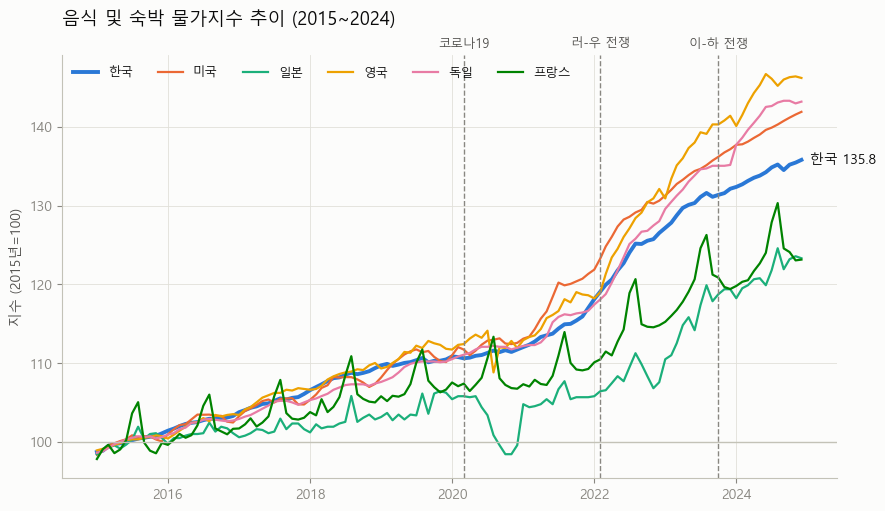

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))
period = cp11.loc[START:END]
for c, name in COUNTRY_NAMES.items():
    ax.plot(period.index, period[c], color=COLORS[c], linewidth=2.8 if c == "KOR" else 1.6, label=name)
ax.annotate(f"한국 {period.loc[END, 'KOR']:.1f}", xy=(period.index[-1], period.loc[END, "KOR"]),
            xytext=(6, 0), textcoords="offset points", va="center", fontsize=10, color="#0b0b0b")
ax.axhline(100, color="#c3c2b7", linewidth=1)
mark_events(ax)
format_year_axis(ax)
ax.set_ylabel("지수 (2015년=100)")
ax.set_title("음식 및 숙박 물가지수 추이 (2015~2024)", loc="left", fontsize=13, pad=22)
ax.legend(ncol=6, loc="upper left", frameon=False, fontsize=9)
fig.savefig(IMG_DIR / "01_index_trend.png")
plt.show()

In [9]:
# 10년 누적 상승률과 연평균 상승률 (2014-12 -> 2024-12)
ratio = cp11.loc[END] / cp11.loc["2014-12-01"]
q1_table = pd.DataFrame({
    "누적상승률(%)": (ratio - 1) * 100,
    "연평균상승률(%)": (ratio ** (1 / 10) - 1) * 100,
})

PERIODS = {
    "2015–2019 코로나 이전": ("2015-01-01", "2019-12-01"),
    "2020–2021 코로나": ("2020-01-01", "2021-12-01"),
    "2022–2024 전쟁·고물가": ("2022-01-01", "2024-12-01"),
}
period_avg = pd.DataFrame({p: yoy_cp11.loc[s:e].mean() for p, (s, e) in PERIODS.items()})
# 외식·숙박 상승률이 전체 물가 상승률보다 얼마나 높았나 (%p)
gap_vs_all = pd.DataFrame({p: (yoy_cp11 - yoy["all_items"]).loc[s:e].mean() for p, (s, e) in PERIODS.items()})

q1_table = q1_table.join(period_avg).rename(index=COUNTRY_NAMES).sort_values("누적상승률(%)", ascending=False)
print("외식·숙박 누적/연평균 상승률과 구간별 평균 전년동월대비 상승률(%)")
display(q1_table.round(2))
print("외식·숙박 상승률 - 전체 CPI 상승률, 구간 평균(%p)")
display(gap_vs_all.rename(index=COUNTRY_NAMES).round(2))

외식·숙박 누적/연평균 상승률과 구간별 평균 전년동월대비 상승률(%)


,누적상승률(%),연평균상승률(%),2015–2019 코로나 이전,2020–2021 코로나,2022–2024 전쟁·고물가
country,,,,,
영국,47.68,3.98,2.55,2.21,7.63
독일,45.90,3.85,2.37,2.35,7.31
미국,45.25,3.80,2.59,3.27,5.87
한국,38.00,3.27,2.42,1.84,5.56
프랑스,25.35,2.29,1.67,0.87,4.27
일본,24.91,2.25,1.33,0.67,4.85


외식·숙박 상승률 - 전체 CPI 상승률, 구간 평균(%p)


,2015–2019 코로나 이전,2020–2021 코로나,2022–2024 전쟁·고물가
country,,,
한국,1.32,0.32,1.89
미국,1.03,0.31,0.84
일본,0.81,0.80,2.01
영국,0.95,0.45,1.62
독일,1.23,0.74,2.27
프랑스,0.83,-0.19,0.23


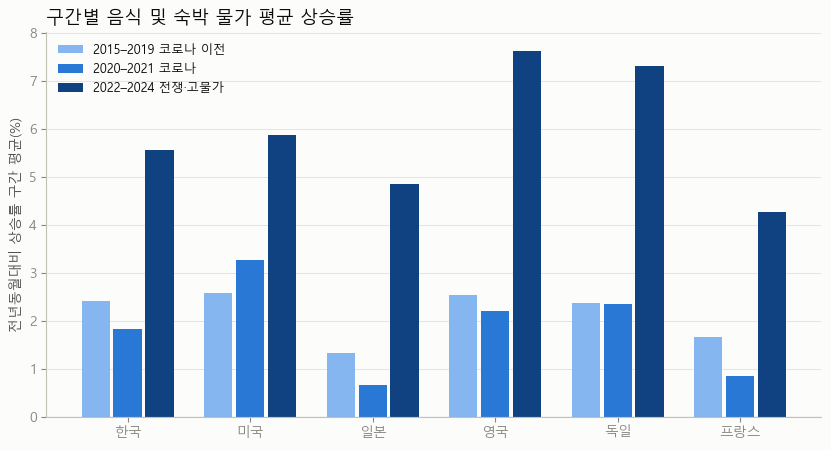

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
order = list(COUNTRY_NAMES)
x = range(len(order))
width = 0.26
period_colors = ["#86b6ef", "#2a78d6", "#104281"]  # 시간 순서를 연한 색 -> 진한 색으로 표현
for i, (p, color) in enumerate(zip(PERIODS, period_colors)):
    values = period_avg.loc[order, p]
    ax.bar([xi + (i - 1) * width for xi in x], values, width=width - 0.03, color=color, label=p)
ax.axhline(0, color="#898781", linewidth=0.8)
ax.set_xticks(list(x), [COUNTRY_NAMES[c] for c in order])
ax.set_ylabel("전년동월대비 상승률 구간 평균(%)")
ax.set_title("구간별 음식 및 숙박 물가 평균 상승률", loc="left", fontsize=13)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
fig.savefig(IMG_DIR / "02_period_avg_yoy.png")
plt.show()

## 5. 질문 2: 급등 구간의 시작 시점과 크기는 나라별로 달랐는가?

**급등 시작 기준:** 2020년 이후 3개월 이동평균 상승률이 평시 기준선(2015–2019 평균 + 2×표준편차)을 **3개월 연속** 넘은 첫 달.
한 달만 넘는 일시적인 튐은 급등으로 보지 않기 위해 3개월 연속 조건을 두었다.

In [11]:
baseline = yoy_cp11.loc["2015-01-01":"2019-12-01"]
threshold = baseline.mean() + 2 * baseline.std()

rows = []
for c, name in COUNTRY_NAMES.items():
    since_2020 = ma_cp11.loc["2020-01-01":, c]
    streak = (since_2020 > threshold[c]).astype(int).rolling(3).sum()
    hits = streak[streak == 3].index
    start = hits[0] - pd.DateOffset(months=2) if len(hits) else pd.NaT
    peak_month = yoy_cp11.loc["2020-01-01":, c].idxmax()
    rows.append({
        "나라": name,
        "평시 평균(%)": baseline[c].mean(),
        "평시 기준선(%)": threshold[c],
        "급등 시작": start.strftime("%Y-%m") if pd.notna(start) else "없음",
        "러-우 전쟁 대비(개월)": (start.year - 2022) * 12 + start.month - 2 if pd.notna(start) else None,
        "정점 월": peak_month.strftime("%Y-%m"),
        "정점 상승률(%)": yoy_cp11.loc[peak_month, c],
    })
surge_table = pd.DataFrame(rows).set_index("나라")
surge_table.round(2)

,평시 평균(%),평시 기준선(%),급등 시작,러-우 전쟁 대비(개월),정점 월,정점 상승률(%)
나라,,,,,,
한국,2.42,3.40,2021-11,-3,2022-08,8.92
미국,2.59,3.42,2021-05,-9,2022-05,9.25
일본,1.33,3.31,2021-08,-6,2023-11,11.77
영국,2.55,3.57,2021-08,-6,2023-02,12.10
독일,2.37,3.01,2021-08,-6,2023-03,10.53
프랑스,1.67,2.61,2022-02,0,2022-07,7.16


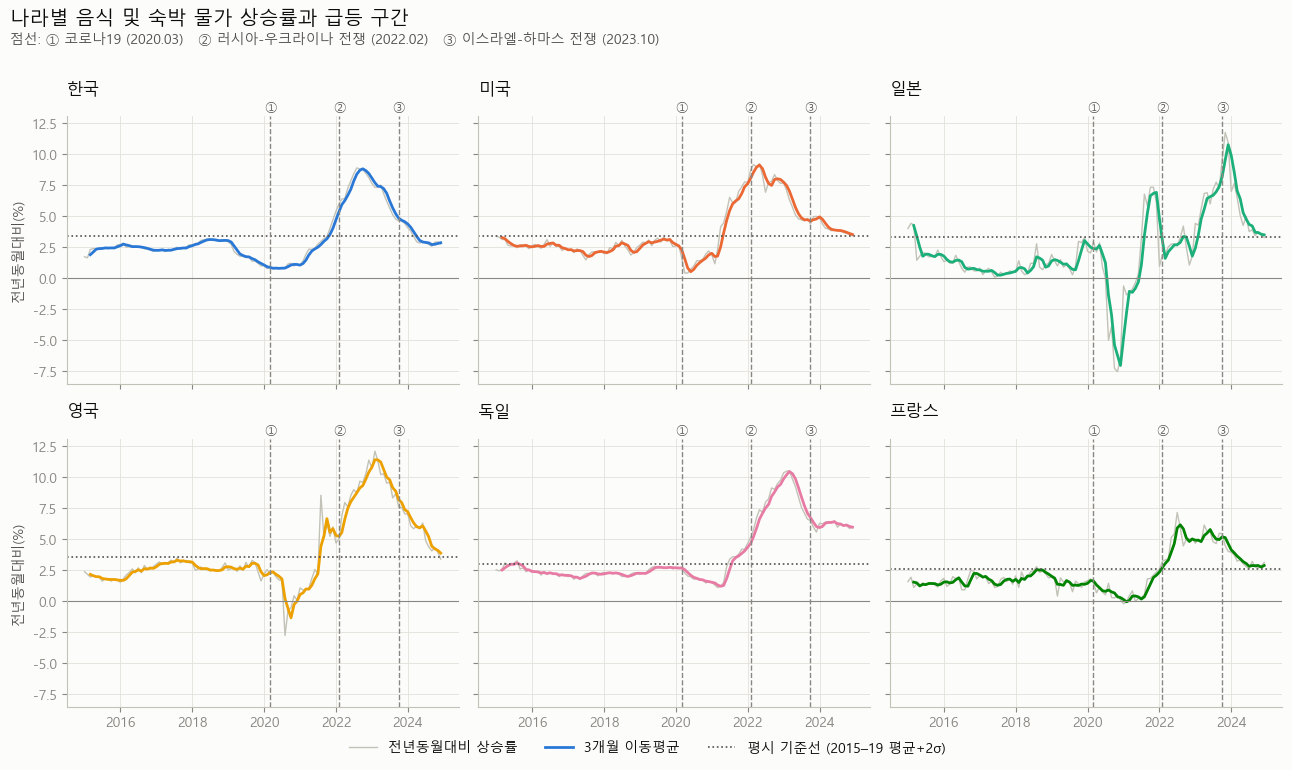

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, (c, name) in zip(axes.flat, COUNTRY_NAMES.items()):
    ax.plot(yoy_cp11.index, yoy_cp11[c], color="#c3c2b7", linewidth=1, label="전년동월대비 상승률")
    ax.plot(ma_cp11.index, ma_cp11[c], color=COLORS[c], linewidth=2, label="3개월 이동평균")
    ax.axhline(threshold[c], color="#52514e", linestyle=":", linewidth=1.2, label="평시 기준선 (2015–19 평균+2σ)")
    ax.axhline(0, color="#898781", linewidth=0.8)
    mark_events(ax, short=True)
    ax.set_title(name, loc="left", fontsize=12, pad=16)
    format_year_axis(ax)
for ax in axes[:, 0]:
    ax.set_ylabel("전년동월대비(%)")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("나라별 음식 및 숙박 물가 상승률과 급등 구간", x=0.01, ha="left", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.text(0.01, 0.935, "점선: ① 코로나19 (2020.03)   ② 러시아-우크라이나 전쟁 (2022.02)   ③ 이스라엘-하마스 전쟁 (2023.10)",
         ha="left", fontsize=10, color="#52514e")
fig.savefig(IMG_DIR / "03_yoy_by_country.png")
plt.show()

### 사건 전후 12개월 비교
각 사건이 일어난 달을 기준으로, **직전 12개월 상승률**과 **직후 12개월 상승률**을 비교한다.
사건 이후 상승 속도가 빨라졌다면 `차이(%p)`가 양수다.

In [13]:
def change_pct(series, start, end):
    return (series.loc[end] / series.loc[start] - 1) * 100

rows = []
for event, date in EVENTS.items():
    before, after = date - pd.DateOffset(months=12), date + pd.DateOffset(months=12)
    for c, name in COUNTRY_NAMES.items():
        rows.append({
            "사건": event,
            "나라": name,
            "직전 12개월(%)": change_pct(cp11[c], before, date),
            "직후 12개월(%)": change_pct(cp11[c], date, after),
        })
event_table = pd.DataFrame(rows)
event_table["차이(%p)"] = event_table["직후 12개월(%)"] - event_table["직전 12개월(%)"]
event_table.pivot(index="나라", columns="사건", values="차이(%p)").loc[list(COUNTRY_NAMES.values()), list(EVENTS)].round(2)

사건,코로나19,러-우 전쟁,이-하 전쟁
나라,,,
한국,1.05,1.34,-1.72
미국,0.68,-1.68,-0.75
일본,-4.17,2.35,-5.87
영국,-1.20,7.07,-3.32
독일,-1.54,5.32,-0.40
프랑스,-1.02,1.78,-2.76


In [14]:
event_table.round(2)

,사건,나라,직전 12개월(%),직후 12개월(%),차이(%p)
0,코로나19,한국,0.88,1.93,1.05
1,코로나19,미국,1.65,2.33,0.68
2,코로나19,일본,2.97,-1.20,-4.17
3,코로나19,영국,2.18,0.98,-1.20
4,코로나19,독일,2.64,1.11,-1.54
5,코로나19,프랑스,1.46,0.45,-1.02
6,러-우 전쟁,한국,6.01,7.35,1.34
7,러-우 전쟁,미국,8.76,7.08,-1.68
8,러-우 전쟁,일본,1.95,4.30,2.35
9,러-우 전쟁,영국,5.03,12.10,7.07


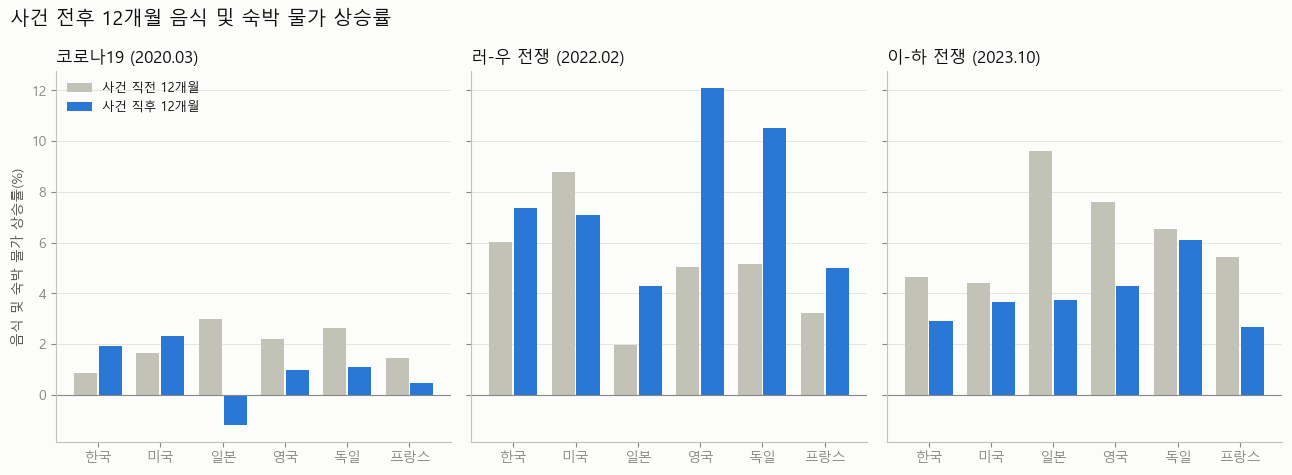

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)
names = list(COUNTRY_NAMES.values())
x = range(len(names))
for ax, event in zip(axes, EVENTS):
    t = event_table[event_table["사건"] == event].set_index("나라").loc[names]
    ax.bar([xi - 0.2 for xi in x], t["직전 12개월(%)"], width=0.37, color="#c3c2b7", label="사건 직전 12개월")
    ax.bar([xi + 0.2 for xi in x], t["직후 12개월(%)"], width=0.37, color="#2a78d6", label="사건 직후 12개월")
    ax.axhline(0, color="#898781", linewidth=0.8)
    ax.set_xticks(list(x), names)
    ax.set_title(f"{event} ({EVENTS[event]:%Y.%m})", loc="left", fontsize=12)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("음식 및 숙박 물가 상승률(%)")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.suptitle("사건 전후 12개월 음식 및 숙박 물가 상승률", x=0.01, ha="left", fontsize=14)
fig.tight_layout()
fig.savefig(IMG_DIR / "04_event_before_after.png")
plt.show()

### 전쟁 영향 경로 확인: 에너지 → 식료품 → 외식
전쟁이 외식 물가에 영향을 줬다면, 원가에 해당하는 **에너지와 식료품 가격이 먼저** 오르고 외식·숙박 물가가 **뒤따라** 올랐을 것이라는 가설을 세웠다.
이를 확인하려고 두 가지를 본다.
1. 2021~2024년 사이 항목별 상승률 **정점 시점의 순서**
2. 에너지·식료품 상승률을 0~12개월 늦췄을 때 외식·숙박 상승률과 **상관계수가 가장 높은 시차**

In [16]:
window = slice("2021-01-01", "2024-12-01")
CATEGORY_LABELS = {"energy": "에너지", "food": "식료품", "restaurants_hotels": "음식 및 숙박"}
peak_month = pd.DataFrame({CATEGORY_LABELS[k]: yoy[k].loc[window].idxmax() for k in CATEGORY_LABELS})
peak_value = pd.DataFrame({CATEGORY_LABELS[k]: yoy[k].loc[window].max() for k in CATEGORY_LABELS})


def months_between(a, b):
    return (b.year - a.year) * 12 + (b.month - a.month)


peak_table = peak_month.apply(lambda col: col.dt.strftime("%Y-%m"))
peak_table["에너지→외식 정점 간격(개월)"] = [months_between(peak_month.loc[c, "에너지"], peak_month.loc[c, "음식 및 숙박"]) for c in peak_month.index]
peak_table["식료품→외식 정점 간격(개월)"] = [months_between(peak_month.loc[c, "식료품"], peak_month.loc[c, "음식 및 숙박"]) for c in peak_month.index]
display(peak_table.rename(index=COUNTRY_NAMES))
print("정점 상승률(%)")
display(peak_value.rename(index=COUNTRY_NAMES).round(2))

,에너지,식료품,음식 및 숙박,에너지→외식 정점 간격(개월),식료품→외식 정점 간격(개월)
country,,,,,
한국,2023-01,2021-02,2022-08,-5,18
미국,2022-06,2022-08,2022-05,-1,-3
일본,2022-03,2023-09,2023-11,20,2
영국,2022-10,2023-03,2023-02,4,-1
독일,2022-10,2023-03,2023-03,5,0
프랑스,2022-06,2023-03,2022-07,1,-8


정점 상승률(%)


,에너지,식료품,음식 및 숙박
country,,,
한국,31.57,9.34,8.92
미국,21.89,13.53,9.25
일본,21.36,9.79,11.77
영국,88.88,19.12,12.10
독일,47.09,21.20,10.53
프랑스,28.50,16.90,7.16


In [17]:
def best_lag(driver, target, max_lag=12):
    """driver를 k개월 늦췄을 때 target과의 상관계수가 가장 큰 k를 찾는다."""
    corrs = {k: target.corr(driver.shift(k)) for k in range(max_lag + 1)}
    k = max(corrs, key=corrs.get)
    return k, corrs[k], corrs[0]


rows = []
for c, name in COUNTRY_NAMES.items():
    for driver in ["energy", "food"]:
        k, r, r0 = best_lag(yoy[driver][c], yoy_cp11[c])
        rows.append({"나라": name, "선행 항목": CATEGORY_LABELS[driver], "최적 시차(개월)": k, "상관계수": r, "시차 0 상관계수": r0})
lag_table = pd.DataFrame(rows).pivot(index="나라", columns="선행 항목").loc[list(COUNTRY_NAMES.values())]
lag_table.round(2)

최적 시차(개월)      상관계수       시차 0 상관계수      
선행 항목       식료품 에너지   식료품   에너지       식료품   에너지
나라                                             
한국           12   0  0.51  0.79      0.40  0.79
미국            0   1  0.77  0.79      0.77  0.78
일본            0  12  0.62  0.38      0.62 -0.05
영국            0   4  0.89  0.74      0.89  0.65
독일            1   4  0.85  0.82      0.84  0.72
프랑스           0   7  0.78  0.85      0.78  0.66

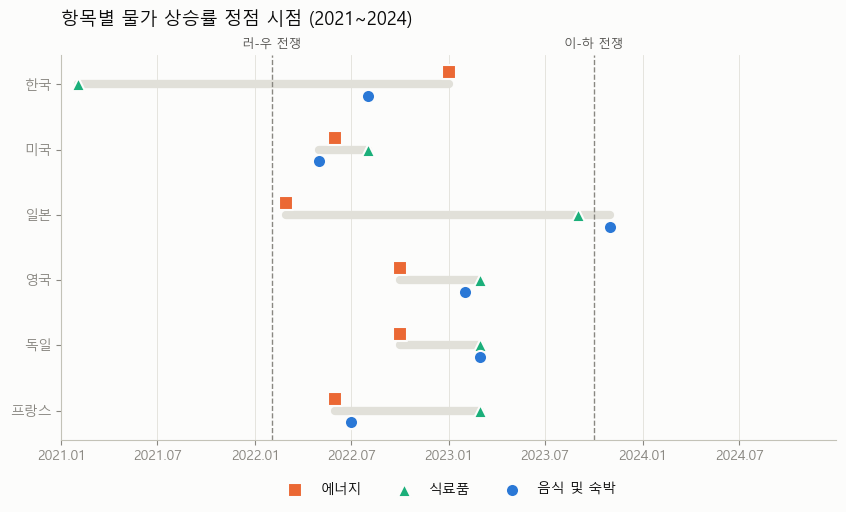

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
# (마커 모양, 색, 세로 위치 보정) - 같은 달에 정점이 겹쳐도 가려지지 않게 위아래로 조금 어긋나게 둔다
markers = {"에너지": ("s", "#eb6834", -0.18), "식료품": ("^", "#1baf7a", 0), "음식 및 숙박": ("o", "#2a78d6", 0.18)}
names = list(COUNTRY_NAMES)
for y, c in enumerate(names):
    dates = peak_month.loc[c]
    ax.plot([dates.min(), dates.max()], [y, y], color="#e1e0d9", linewidth=6, solid_capstyle="round", zorder=1)
    for label, (marker, color, offset) in markers.items():
        ax.scatter(dates[label], y + offset, marker=marker, s=90, color=color, edgecolor="#fcfcfb", linewidth=1.5,
                   zorder=3, label=label if y == 0 else None)
for event in ["러-우 전쟁", "이-하 전쟁"]:
    ax.axvline(EVENTS[event], color="#898781", linestyle="--", linewidth=1)
    ax.text(EVENTS[event], 1.01, event, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=9, color="#52514e")
ax.set_yticks(range(len(names)), [COUNTRY_NAMES[c] for c in names])
ax.invert_yaxis()
ax.set_xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2024-12-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y.%m"))
ax.grid(axis="y", visible=False)
ax.set_title("항목별 물가 상승률 정점 시점 (2021~2024)", loc="left", fontsize=13, pad=22)
ax.legend(frameon=False, fontsize=10, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.savefig(IMG_DIR / "05_peak_timing.png")
plt.show()

## 6. 보너스 (A): 시계열 분해 (STL)

물가지수를 **추세 + 계절성 + 잔차(노이즈)** 세 부분으로 나눈다.
- **방법:** STL(Seasonal-Trend decomposition using LOESS), 주기 12개월, 튀는 값의 영향을 줄이는 `robust=True`
- **계절성 강도:** `1 - Var(잔차) / Var(계절 + 잔차)`로 계산한다. 0에 가까우면 계절 패턴이 거의 없고, 1에 가까우면 계절 패턴이 뚜렷하다.
- **비교 대상:** 한국과 프랑스. 프랑스는 매년 9월 이상치 후보가 반복되어 계절성이 강할 것으로 예상했다.

In [19]:
from statsmodels.tsa.seasonal import STL

stl_results = {c: STL(cp11.loc[START:END, c], period=12, robust=True).fit() for c in COUNTRY_NAMES}


def seasonal_strength(result):
    return max(0.0, 1 - result.resid.var() / (result.seasonal + result.resid).var())


decomp_table = pd.DataFrame({
    "계절성 강도(0~1)": {COUNTRY_NAMES[c]: seasonal_strength(r) for c, r in stl_results.items()},
    "2024년 계절 요인 폭(지수)": {COUNTRY_NAMES[c]: r.seasonal.loc["2024"].max() - r.seasonal.loc["2024"].min() for c, r in stl_results.items()},
    "계절 요인 최고 월": {COUNTRY_NAMES[c]: r.seasonal.loc["2024"].idxmax().month for c, r in stl_results.items()},
    "계절 요인 최저 월": {COUNTRY_NAMES[c]: r.seasonal.loc["2024"].idxmin().month for c, r in stl_results.items()},
    "잔차 표준편차(지수)": {COUNTRY_NAMES[c]: r.resid.std() for c, r in stl_results.items()},
    "추세 10년 변화(지수)": {COUNTRY_NAMES[c]: r.trend.iloc[-1] - r.trend.iloc[0] for c, r in stl_results.items()},
})
decomp_table.sort_values("계절성 강도(0~1)", ascending=False).round(3)

,계절성 강도(0~1),2024년 계절 요인 폭(지수),계절 요인 최고 월,계절 요인 최저 월,잔차 표준편차(지수),추세 10년 변화(지수)
프랑스,0.952,8.630,8,12,0.450,26.143
미국,0.382,0.324,11,2,0.673,43.067
독일,0.284,3.403,6,12,0.646,46.427
일본,0.190,5.630,8,2,1.444,23.508
한국,0.121,1.018,8,9,0.497,37.232
영국,0.000,4.550,6,12,1.336,49.335


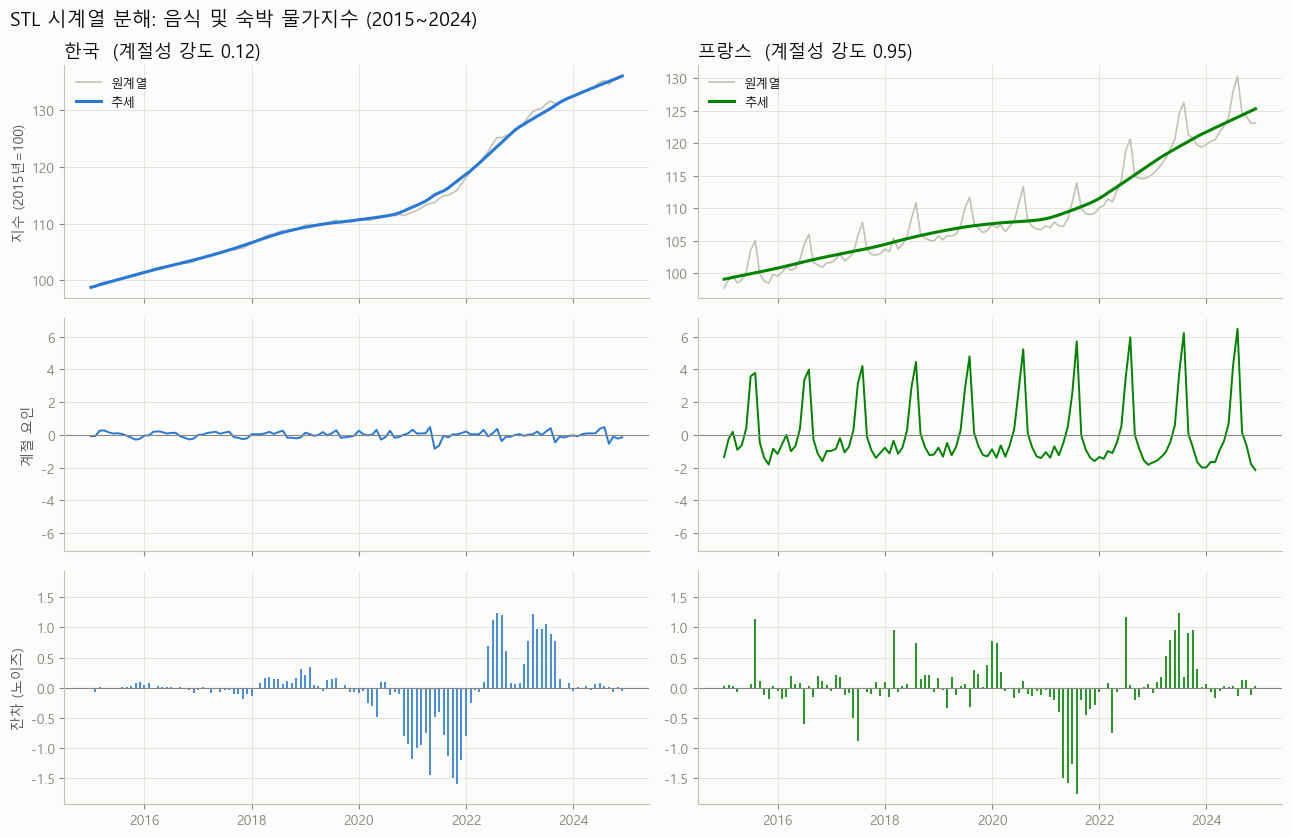

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8.5), sharex=True)
pair = ["KOR", "FRA"]
for col, c in enumerate(pair):
    res = stl_results[c]
    top = axes[0, col]
    top.plot(res.observed.index, res.observed, color="#c3c2b7", linewidth=1.2, label="원계열")
    top.plot(res.trend.index, res.trend, color=COLORS[c], linewidth=2.2, label="추세")
    top.set_title(f"{COUNTRY_NAMES[c]}  (계절성 강도 {seasonal_strength(res):.2f})", loc="left", fontsize=13)
    top.legend(frameon=False, fontsize=9, loc="upper left")
    axes[1, col].plot(res.seasonal.index, res.seasonal, color=COLORS[c], linewidth=1.4)
    axes[2, col].vlines(res.resid.index, 0, res.resid, color=COLORS[c], linewidth=1.2)
    for row in (1, 2):
        axes[row, col].axhline(0, color="#898781", linewidth=0.8)
    format_year_axis(axes[2, col])

# 계절 요인과 잔차는 두 나라의 크기를 비교할 수 있게 같은 세로축 범위를 쓴다
for row, part in ((1, "seasonal"), (2, "resid")):
    limit = max(getattr(stl_results[c], part).abs().max() for c in pair) * 1.1
    for col in range(2):
        axes[row, col].set_ylim(-limit, limit)
axes[0, 0].set_ylabel("지수 (2015년=100)")
axes[1, 0].set_ylabel("계절 요인")
axes[2, 0].set_ylabel("잔차 (노이즈)")
fig.suptitle("STL 시계열 분해: 음식 및 숙박 물가지수 (2015~2024)", x=0.01, ha="left", fontsize=14)
fig.tight_layout()
fig.savefig(IMG_DIR / "06_stl_decomposition.png")
plt.show()

## 7. 보너스 (B): 간단 예측 (베이스라인)

2015-01 ~ 2024-12 데이터만 보고 **2025년 12개월**을 예측한 뒤, 이미 발표된 2025년 실제값과 비교한다.
정확도를 높이는 것이 목적이 아니라, **어떤 가정이 어느 정도 맞았는지** 확인하는 것이 목적이다.

| 방법 | 가정 |
|---|---|
| 단순 (마지막 값 유지) | 앞으로 물가가 더 오르지 않는다 |
| 계절 단순 (작년 같은 달) | 작년과 똑같은 모양이 반복된다 (추세는 반영하지 않음) |
| 추세 유지 (최근 12개월 기울기) | 최근 1년의 평균 월 상승 폭이 그대로 이어진다 |

- **평가 지표:** MAE(평균 절대 오차, 지수 단위), MAPE(평균 절대 백분율 오차, %)
- **미국 제외:** 미국 음식 및 숙박 지수는 2024-12에서 끝나 2025년 실제값이 없다.

In [21]:
full = df[df["category"] == "restaurants_hotels"].pivot(index="date", columns="country", values="index")
test_months = pd.date_range("2025-01-01", "2025-12-01", freq="MS")


def baseline_forecasts(train):
    last = train.iloc[-1]
    monthly_slope = (train.iloc[-1] - train.iloc[-13]) / 12  # 최근 12개월 평균 월 변화량
    return pd.DataFrame({
        "단순 (마지막 값 유지)": [last] * 12,
        "계절 단순 (작년 같은 달)": train.iloc[-12:].to_numpy(),
        "추세 유지 (최근 12개월 기울기)": [last + monthly_slope * h for h in range(1, 13)],
    }, index=test_months)


forecasts, rows = {}, []
for c, name in COUNTRY_NAMES.items():
    actual = full[c].reindex(test_months)
    if actual.isna().any():
        print(f"{name}: 2025년 실제값이 없어 평가에서 제외")
        continue
    forecasts[c] = baseline_forecasts(full.loc[START:END, c])
    for method in forecasts[c]:
        error = forecasts[c][method] - actual
        rows.append({
            "나라": name,
            "방법": method,
            "MAE": error.abs().mean(),
            "MAPE(%)": (error.abs() / actual).mean() * 100,
            "2025-12 오차(지수)": error.iloc[-1],
        })

forecast_table = pd.DataFrame(rows)
mape = forecast_table.pivot(index="나라", columns="방법", values="MAPE(%)")
mape["가장 정확한 방법"] = mape.idxmin(axis=1)
display(mape.round(2))
forecast_table.round(2)

미국: 2025년 실제값이 없어 평가에서 제외


방법,계절 단순 (작년 같은 달),단순 (마지막 값 유지),추세 유지 (최근 12개월 기울기),가장 정확한 방법
나라,,,,
독일,3.67,2.56,0.55,추세 유지 (최근 12개월 기울기)
영국,3.23,2.41,0.81,추세 유지 (최근 12개월 기울기)
일본,4.37,2.89,1.27,추세 유지 (최근 12개월 기울기)
프랑스,2.32,2.55,1.38,추세 유지 (최근 12개월 기울기)
한국,3.00,1.86,0.43,추세 유지 (최근 12개월 기울기)


,나라,방법,MAE,MAPE(%),2025-12 오차(지수)
0,한국,단순 (마지막 값 유지),2.58,1.86,-4.07
1,한국,계절 단순 (작년 같은 달),4.15,3.00,-4.07
2,한국,추세 유지 (최근 12개월 기울기),0.60,0.43,-0.40
3,일본,단순 (마지막 값 유지),3.70,2.89,-5.46
4,일본,계절 단순 (작년 같은 달),5.56,4.37,-5.46
5,일본,추세 유지 (최근 12개월 기울기),1.63,1.27,-1.52
6,영국,단순 (마지막 값 유지),3.63,2.41,-5.60
7,영국,계절 단순 (작년 같은 달),4.83,3.23,-5.60
8,영국,추세 유지 (최근 12개월 기울기),1.21,0.81,-0.80
9,독일,단순 (마지막 값 유지),3.78,2.56,-5.13


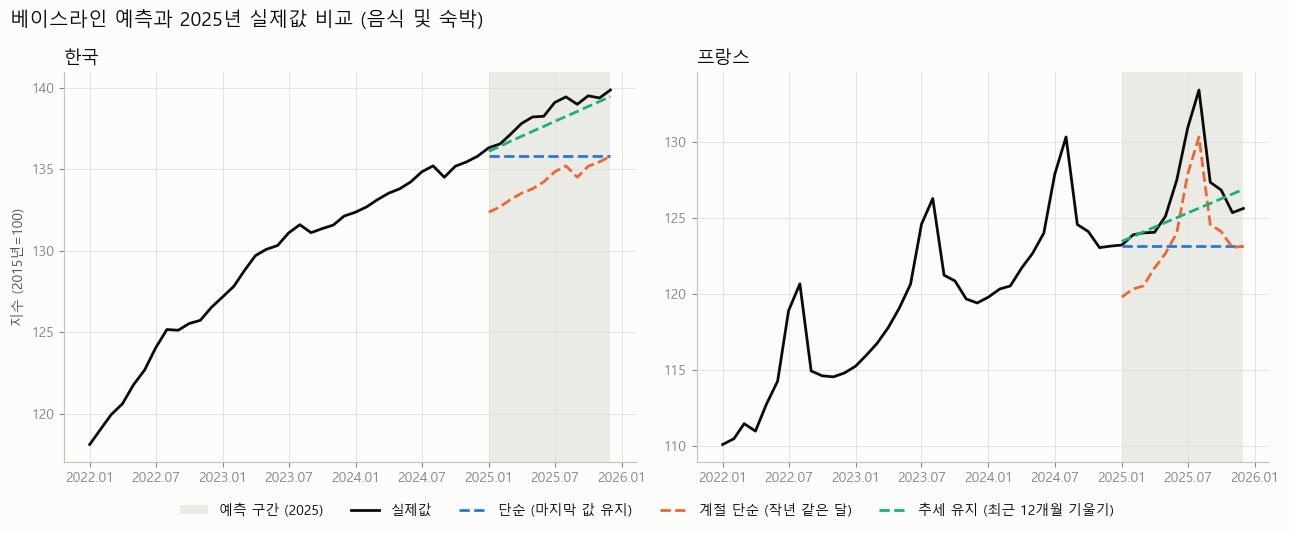

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
method_colors = {
    "단순 (마지막 값 유지)": "#2a78d6",
    "계절 단순 (작년 같은 달)": "#eb6834",
    "추세 유지 (최근 12개월 기울기)": "#1baf7a",
}
for ax, c in zip(axes, ["KOR", "FRA"]):
    ax.axvspan(test_months[0], test_months[-1], color="#e1e0d9", alpha=0.6, linewidth=0, label="예측 구간 (2025)")
    history = full.loc["2022-01-01":"2025-12-01", c]
    ax.plot(history.index, history, color="#0b0b0b", linewidth=2, label="실제값")
    for method, color in method_colors.items():
        ax.plot(forecasts[c].index, forecasts[c][method], color=color, linewidth=2, linestyle="--", label=method)
    ax.set_title(COUNTRY_NAMES[c], loc="left", fontsize=13)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y.%m"))
axes[0].set_ylabel("지수 (2015년=100)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("베이스라인 예측과 2025년 실제값 비교 (음식 및 숙박)", x=0.01, ha="left", fontsize=14)
fig.tight_layout()
fig.savefig(IMG_DIR / "07_baseline_forecast.png")
plt.show()

## 8. 심화: 한국 외식 물가는 무엇이 밀어올렸나

5-5에서 한국만 외식 물가 정점(2022-08)이 국내 에너지 정점(2023-01)보다 **먼저** 왔다.
전기·가스 요금은 정부가 인상 시점을 조절하므로, 국내 에너지 지수로는 원가 압력이 언제 왔는지 알기 어렵다.
그래서 **요금 규제를 받지 않는 지표**로 다시 확인한다. (`collect_cost_drivers.py`로 수집)

| 지표 | 내용 | 왜 보는가 |
|---|---|---|
| 원화 기준 유가 | 브렌트유 × 원/달러 환율 | 음식점이 실제로 부담하는 수입 에너지 비용에 가깝다 |
| 원화 기준 세계 식료품 가격 | IMF 식료품 가격지수 × 환율 | 수입 식재료 원가 |
| 국내 에너지 (CP045) | 전기·가스·연료 소비자물가 | 규제 지표와의 차이를 보기 위한 비교 대상 |
| 최저임금 | 한국 법정 시급 | 리포트에서 가설로만 언급했던 인건비 요인 |

In [23]:
drivers = pd.read_csv("data/cost_drivers_monthly.csv", parse_dates=["date"]).set_index("date")
wage = pd.read_csv("data/kor_minimum_wage.csv")
full_cpi = df.pivot_table(index="date", columns=["country", "category"], values="index").asfreq("MS")

kor = pd.DataFrame({
    "외식·숙박": full_cpi[("KOR", "restaurants_hotels")],
    "국내 식료품": full_cpi[("KOR", "food")],
    "국내 에너지": full_cpi[("KOR", "energy")],
    "원화 유가": drivers["brent_krw"],
    "원화 세계식료품": drivers["food_index_krw"],
    "달러 유가": drivers["brent_usd"],
    "원/달러 환율": drivers["usdkrw"],
})
kor_yoy = (kor.pct_change(12) * 100).loc[START:]

print("한국 음식 및 숙박 지수 최신값")
latest = full_cpi[("KOR", "restaurants_hotels")].dropna()
print(f"  {latest.index[-1]:%Y-%m}: {latest.iloc[-1]:.2f}  (2015년=100 기준 {latest.iloc[-1] - 100:+.1f}%)")
print(f"  분석 기간 끝(2024-12): {latest.loc['2024-12-01']:.2f}")
print(f"  최근 전년동월대비: {kor_yoy['외식·숙박'].dropna().iloc[-1]:.2f}%")
kor_yoy.tail(6).round(2)

한국 음식 및 숙박 지수 최신값
  2026-08: 143.41  (2015년=100 기준 +43.4%)
  분석 기간 끝(2024-12): 135.80
  최근 전년동월대비: 2.85%


,외식·숙박,국내 식료품,국내 에너지,원화 유가,원화 세계식료품,달러 유가,원/달러 환율
date,,,,,,,
2026-03-01,2.74,0.51,0.41,44.93,8.20,41.80,2.21
2026-04-01,2.64,0.28,0.87,77.42,11.09,72.16,3.06
2026-05-01,2.65,1.61,1.14,77.82,15.41,66.24,6.97
2026-06-01,2.66,2.03,1.26,33.98,16.99,19.54,12.07
2026-07-01,2.76,0.95,1.43,27.03,12.88,17.91,7.74
2026-08-01,2.85,-0.54,1.43,35.57,13.63,34.20,1.02


### 8-1. 원가 지표와 외식 물가의 시차
각 원가 지표를 0~18개월 늦췄을 때 외식 물가 상승률과의 상관계수가 가장 높아지는 시차를 찾는다.
분석 기간(2015-01 ~ 2024-12)으로 계산한다.

In [24]:
def best_lag(driver, target, max_lag=18):
    corrs = {k: target.corr(driver.shift(k)) for k in range(max_lag + 1)}
    k = max(corrs, key=corrs.get)
    return k, corrs[k], corrs[0]


target = kor_yoy.loc[START:END, "외식·숙박"]
rows = []
for name in ["원화 유가", "달러 유가", "원화 세계식료품", "국내 에너지", "국내 식료품"]:
    lag, corr, corr0 = best_lag(kor_yoy.loc[START:END, name], target)
    rows.append({"지표": name, "최적 시차(개월)": lag, "상관계수": corr, "시차 0 상관계수": corr0})
lag_table = pd.DataFrame(rows).set_index("지표")
display(lag_table.round(2))

window = slice("2021-01-01", "2024-12-01")
peaks = pd.DataFrame({
    "상승률 정점 월": kor_yoy.loc[window].idxmax().dt.strftime("%Y-%m"),
    "정점 상승률(%)": kor_yoy.loc[window].max().round(1),
    "가격 수준 정점 월": kor.loc[window].idxmax().dt.strftime("%Y-%m"),
})
print("2021~2024년 정점 (상승률 기준 / 가격 수준 기준)")
display(peaks)
print("주의: 원화·달러 유가의 상승률 정점(2021-04)은 2020년 4월 유가 폭락에 따른 기저효과다.")
print("      원가 지표는 '가격 수준 정점'을, 소비자물가는 계속 오르므로 '상승률 정점'을 본다.")

,최적 시차(개월),상관계수,시차 0 상관계수
지표,,,
원화 유가,10,0.66,0.31
달러 유가,11,0.61,0.21
원화 세계식료품,10,0.77,0.37
국내 에너지,0,0.79,0.79
국내 식료품,17,0.61,0.40


2021~2024년 정점 (상승률 기준 / 가격 수준 기준)


,상승률 정점 월,정점 상승률(%),가격 수준 정점 월
외식·숙박,2022-08,8.9,2024-12
국내 식료품,2021-02,9.3,2024-09
국내 에너지,2023-01,31.6,2024-12
원화 유가,2021-04,222.3,2022-06
원화 세계식료품,2022-03,41.9,2022-05
달러 유가,2021-04,252.6,2022-06
원/달러 환율,2022-10,20.7,2024-12


주의: 원화·달러 유가의 상승률 정점(2021-04)은 2020년 4월 유가 폭락에 따른 기저효과다.
      원가 지표는 '가격 수준 정점'을, 소비자물가는 계속 오르므로 '상승률 정점'을 본다.


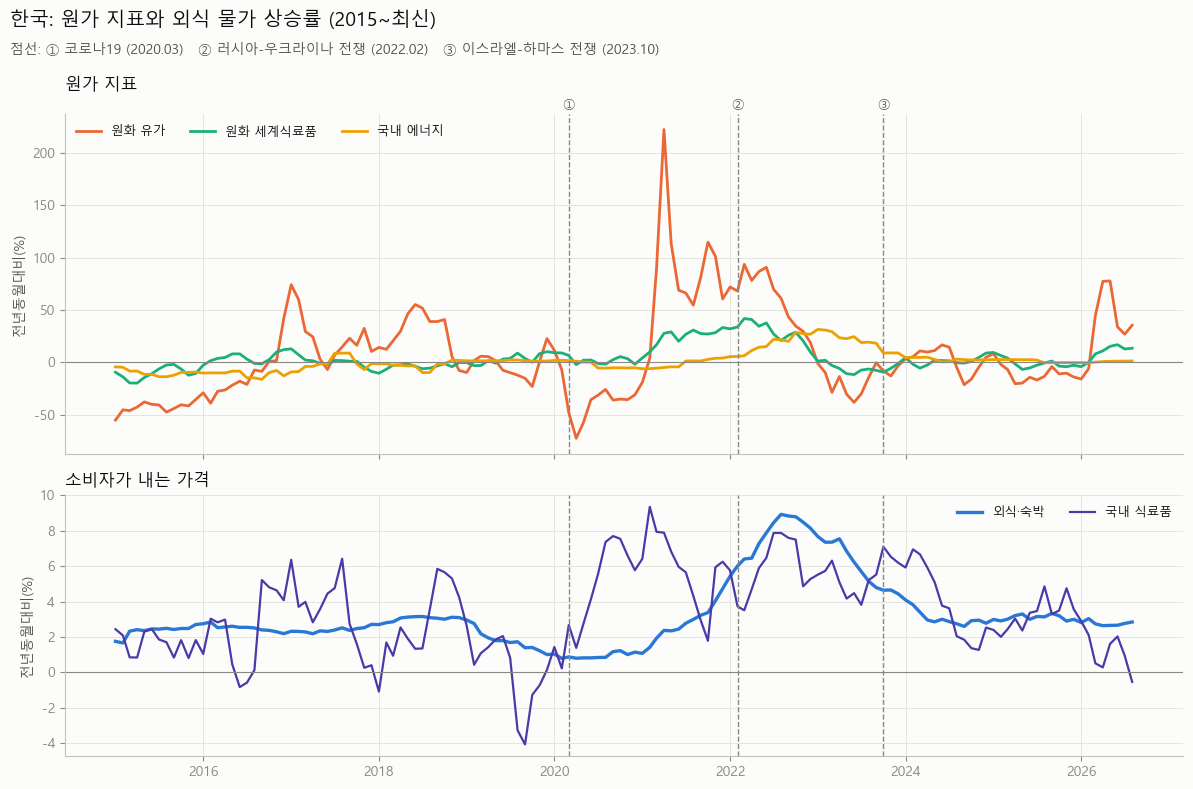

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [1.3, 1]})
driver_colors = {"원화 유가": "#eb6834", "원화 세계식료품": "#1baf7a", "국내 에너지": "#eda100"}
for name, color in driver_colors.items():
    axes[0].plot(kor_yoy.index, kor_yoy[name], color=color, linewidth=2, label=name)
axes[0].axhline(0, color="#898781", linewidth=0.8)
axes[0].set_ylabel("전년동월대비(%)")
axes[0].set_title("원가 지표", loc="left", fontsize=12, pad=18)
axes[0].legend(frameon=False, fontsize=9, ncol=3)

axes[1].plot(kor_yoy.index, kor_yoy["외식·숙박"], color=COLORS["KOR"], linewidth=2.4, label="외식·숙박")
axes[1].plot(kor_yoy.index, kor_yoy["국내 식료품"], color="#4a3aa7", linewidth=1.6, label="국내 식료품")
axes[1].axhline(0, color="#898781", linewidth=0.8)
axes[1].set_ylabel("전년동월대비(%)")
axes[1].set_title("소비자가 내는 가격", loc="left", fontsize=12, pad=6)
axes[1].legend(frameon=False, fontsize=9, ncol=2)

for ax in axes:
    mark_events(ax, label=(ax is axes[0]), short=True)
    format_year_axis(ax)
fig.suptitle("한국: 원가 지표와 외식 물가 상승률 (2015~최신)", x=0.01, ha="left", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.text(0.01, 0.925, "점선: ① 코로나19 (2020.03)   ② 러시아-우크라이나 전쟁 (2022.02)   ③ 이스라엘-하마스 전쟁 (2023.10)",
         ha="left", fontsize=10, color="#52514e")
fig.savefig(IMG_DIR / "08_kor_cost_drivers.png")
plt.show()

### 8-2. 인건비(최저임금)와 외식 물가
최저임금은 연 1회 결정되므로 연 단위로 비교한다. 관측치가 10개뿐이라 상관계수는 참고용이다.

In [26]:
annual_cpi = kor_yoy["외식·숙박"].groupby(kor_yoy.index.year).mean()
wage_compare = wage.set_index("year").join(annual_cpi.rename("외식 연평균 상승률(%)")).dropna()
wage_compare = wage_compare.rename(columns={"hourly_krw": "최저임금(원)", "yoy_pct": "최저임금 인상률(%)"})
display(wage_compare.round(2))
print("같은 해 상관계수:", round(wage_compare["최저임금 인상률(%)"].corr(wage_compare["외식 연평균 상승률(%)"]), 2))
print("최저임금 1년 선행 상관계수:",
      round(wage_compare["최저임금 인상률(%)"].shift(1).corr(wage_compare["외식 연평균 상승률(%)"]), 2))

,최저임금(원),최저임금 인상률(%),외식 연평균 상승률(%)
year,,,
2015,5580,7.10,2.33
2016,6030,8.06,2.51
2017,6470,7.30,2.40
2018,7530,16.38,3.02
2019,8350,10.89,1.82
2020,8590,2.87,0.95
2021,8720,1.51,2.73
2022,9160,5.05,7.58
2023,9620,5.02,6.03


같은 해 상관계수: -0.11
최저임금 1년 선행 상관계수: -0.62


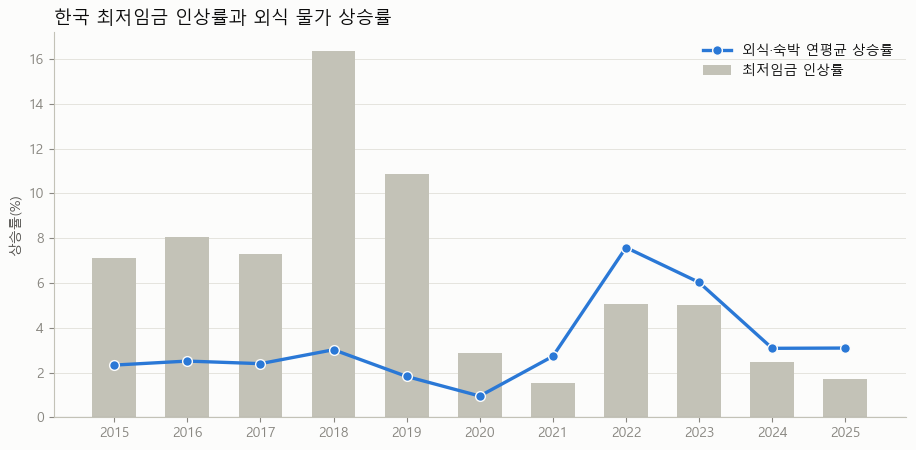

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
years = wage_compare.index
ax.bar(years, wage_compare["최저임금 인상률(%)"], color="#c3c2b7", width=0.6, label="최저임금 인상률")
ax.plot(years, wage_compare["외식 연평균 상승률(%)"], color=COLORS["KOR"], linewidth=2.4,
        marker="o", markersize=7, markeredgecolor="#fcfcfb", label="외식·숙박 연평균 상승률")
ax.axhline(0, color="#898781", linewidth=0.8)
ax.set_ylabel("상승률(%)")
ax.set_xticks(list(years))
ax.grid(axis="x", visible=False)
ax.set_title("한국 최저임금 인상률과 외식 물가 상승률", loc="left", fontsize=13)
ax.legend(frameon=False, fontsize=10)
fig.savefig(IMG_DIR / "09_kor_minimum_wage.png")
plt.show()

## 9. 정리
위 표와 그래프에서 확인한 **관찰(수치)**과 그에 대한 **해석(가설)**, 결론과 한계점은 `REPORT.md`에 정리한다.